In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def read_spenvis_csv_to_df(filename):
    reading_spectra=False
    reading_objects=False
    energy = None
    int_spectra_data = []
    diff_spectra_data = []
    angle_data=[]
    
    data={}
    linenumber=0
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            line = line.replace("'","")
#            print(linenumber,len(line.split(',')))
            # Identify the location in the file
            if line.startswith("PRJ_DEF"): #starting the section with tag, length, value, unit
                reading_objects=True
            elif line.startswith("DFlux"):
                reading_objects=False
                reading_spectra=True
                continue
            elif line.startswith("End of File"):
                reading_spectra=False
                reading_objects=False
                break #done with file, end the loop
            if reading_objects and line.startswith("Mission start"):
                reading_objects=False
                continue
                

            if reading_spectra:
                # Convert the row of spectra values to floats and append
                length_energy=data["ENERGY"]["length"]
                row_values = [float(val) for val in line.split(',')[0:2]]
                angle_data.append(row_values)
                row_values = [float(val) for val in line.split(',')[4:4+length_energy]]
                int_spectra_data.append(row_values)
                row_values = [float(val) for val in line.split(',')[4+length_energy:]]                
                diff_spectra_data.append(row_values)
            if reading_objects and len(line.split(','))>1 and len(line.split(','))==int(line.split(',')[1])+3:
                name=line.split(',')[0]
                array_length=int(line.split(',')[1])
                values=[float(v) for v in line.split(',')[2:-1]] #get the values
                units=line.split(',')[-1]
                data[name]={"values": values, "units": units,"length":array_length}
            linenumber+=1
    data["angle"]={"values": angle_data, "units":"Gaus, L"}
    data["int_spectra"]={"values": int_spectra_data, "units":"cm^2 s^-1"}
    data["diff_spectra"]={"values": diff_spectra_data, "units":"cm^2 s^-1 MeV^-1"}
    print("Read ",len(data["int_spectra"]["values"]), "lines of spectra.")
    return data

In [34]:
if __name__ == "__main__":
    # Example usage:
    data = read_spenvis_csv_to_df('data_anisotropicity/spenvis_ano.cvs')

Read  180 lines of spectra.


In [35]:
np.array(data["angle"]["values"])[:,1]

array([ 12.,  36.,  60.,  84., 108., 132., 156., 180., 204., 228., 252.,
       276., 300., 324., 348.,  12.,  36.,  60.,  84., 108., 132., 156.,
       180., 204., 228., 252., 276., 300., 324., 348.,  12.,  36.,  60.,
        84., 108., 132., 156., 180., 204., 228., 252., 276., 300., 324.,
       348.,  12.,  36.,  60.,  84., 108., 132., 156., 180., 204., 228.,
       252., 276., 300., 324., 348.,  12.,  36.,  60.,  84., 108., 132.,
       156., 180., 204., 228., 252., 276., 300., 324., 348.,  12.,  36.,
        60.,  84., 108., 132., 156., 180., 204., 228., 252., 276., 300.,
       324., 348.,  12.,  36.,  60.,  84., 108., 132., 156., 180., 204.,
       228., 252., 276., 300., 324., 348.,  12.,  36.,  60.,  84., 108.,
       132., 156., 180., 204., 228., 252., 276., 300., 324., 348.,  12.,
        36.,  60.,  84., 108., 132., 156., 180., 204., 228., 252., 276.,
       300., 324., 348.,  12.,  36.,  60.,  84., 108., 132., 156., 180.,
       204., 228., 252., 276., 300., 324., 348.,  1

<IPython.core.display.Javascript object>


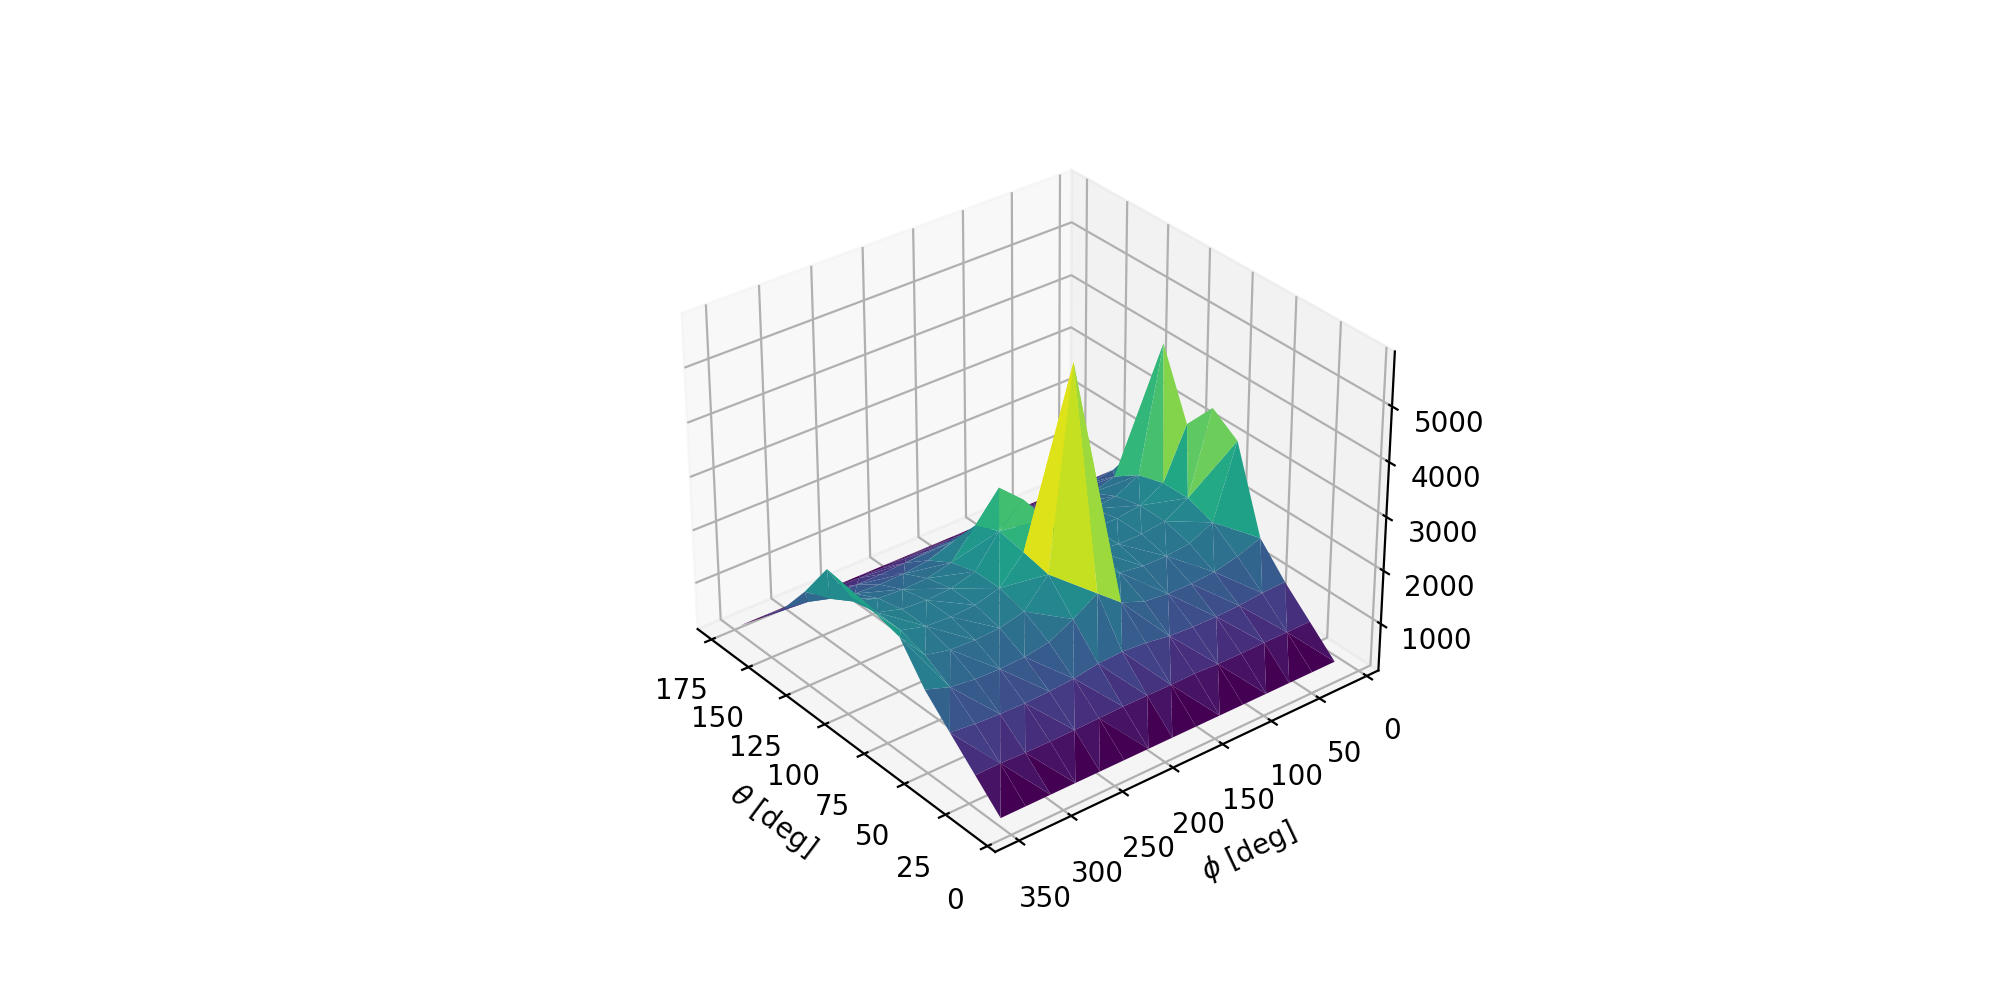

In [91]:
%matplotlib notebook

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='3d')
theta=np.array(data["angle"]["values"])[:,0]
phi=np.array(data["angle"]["values"])[:,1]
integral=np.array(data["int_spectra"]["values"])[:,1]
surface = ax.plot_trisurf((theta),phi,integral,cmap='viridis')
ax.set_ylabel(r'$\phi$ [deg]')
ax.set_xlabel(r'$ \theta $ [deg]')
ax.view_init(elev=30, azim=30)
#for angle in range(0, 360):
#    ax.view_init(elev=30, azim=angle)
#    plt.draw()
#    plt.pause(0.01)  # Adjust pause time for rotation speed
plt.show()

In [54]:
print(phi,integral)

[ 12.  36.  60.  84. 108. 132. 156. 180. 204. 228. 252. 276. 300. 324.
 348.  12.  36.  60.  84. 108. 132. 156. 180. 204. 228. 252. 276. 300.
 324. 348.  12.  36.  60.  84. 108. 132. 156. 180. 204. 228. 252. 276.
 300. 324. 348.  12.  36.  60.  84. 108. 132. 156. 180. 204. 228. 252.
 276. 300. 324. 348.  12.  36.  60.  84. 108. 132. 156. 180. 204. 228.
 252. 276. 300. 324. 348.  12.  36.  60.  84. 108. 132. 156. 180. 204.
 228. 252. 276. 300. 324. 348.  12.  36.  60.  84. 108. 132. 156. 180.
 204. 228. 252. 276. 300. 324. 348.  12.  36.  60.  84. 108. 132. 156.
 180. 204. 228. 252. 276. 300. 324. 348.  12.  36.  60.  84. 108. 132.
 156. 180. 204. 228. 252. 276. 300. 324. 348.  12.  36.  60.  84. 108.
 132. 156. 180. 204. 228. 252. 276. 300. 324. 348.  12.  36.  60.  84.
 108. 132. 156. 180. 204. 228. 252. 276. 300. 324. 348.  12.  36.  60.
  84. 108. 132. 156. 180. 204. 228. 252. 276. 300. 324. 348.] [0.113581 0.113581 0.113581 0.113581 0.113581 0.113581 0.113581 0.113581
 0.113581 0.1